# NB7 — Comparaison Finale et Sélection du Modèle de Déploiement

## Contexte

Ce notebook clôt la phase de modélisation du projet de classification
de tweets disaster/non-disaster. Il synthétise et compare les résultats
de **tous les modèles** testés dans les notebooks précédents pour
identifier le candidat optimal pour le déploiement final.

---

## Objectifs

1. **Consolider** les résultats des 6 notebooks de modélisation (NB1 à NB6)
2. **Comparer** les 30 modèles selon plusieurs métriques
3. **Visualiser** les performances par notebook et par catégorie d'approche
4. **Sélectionner** le meilleur modèle pour le déploiement
5. **Préparer** les fichiers nécessaires pour le dashboard Streamlit et
   l'interface interactive Gradio

---

## Récapitulatif des notebooks de modélisation

| Notebook | Approche | Nombre de modèles |
|---|---|---|
| **NB1** | Count + TF-IDF Word (baselines) | 5 |
| **NB2** | TF-IDF Char + Hybrid | 5 |
| **NB3** | Naive Bayes complet + SGD + Features numériques | 5 |
| **NB4** | Embeddings (Word2Vec, GloVe Twitter) | 5 |
| **NB5** | Méthodes ensemblistes (RF, XGB, LGBM, Voting, Stacking) | 5 |
| **NB6** | Deep Learning (Transformers, BiLSTM, TextCNN) | 5 |
| **TOTAL** | | **30 modèles** |

---

## Approche

### 1. Chargement et consolidation
On charge les fichiers CSV de résultats de chaque notebook et on les
combine dans un tableau unique avec une colonne `categorie` pour
faciliter les analyses comparatives.

### 2. Analyses comparatives
Plusieurs visualisations permettent d'analyser les performances sous
différents angles :

* **TOP 10 global** — quels sont les meilleurs modèles toutes catégories
  confondues ?
* **Meilleur par notebook** — quelle approche a donné le meilleur résultat
  dans chaque famille ?
* **Distribution par catégorie** (boxplot) — quelle catégorie est la plus
  stable et la plus performante ?
* **Heatmap multi-métriques** — comparaison du TOP 10 sur toutes les métriques
* **Trade-off Precision/Recall** — quels modèles privilégient quoi ?
* **Évolution historique** — illustration de l'apport du deep learning

### 3. Sélection finale
Le modèle final est choisi selon plusieurs critères :
* **F1-score classe 1** (métrique principale)
* **Recall classe 1** (priorité opérationnelle)
* **Robustesse et reproductibilité**

---

## Métriques utilisées

* **F1-score classe 1** : équilibre précision/rappel sur la classe disaster
* **Recall classe 1** : taux de détection des vrais disasters
* **Precision classe 1** : qualité des prédictions disaster
* **Accuracy** : performance globale
* **Balanced accuracy** : moyenne du recall sur les deux classes

---

## Output de ce notebook

À l'issue de ce notebook, plusieurs livrables sont produits :

1. **`all_models_comparison.csv`** : tableau consolidé des 30 modèles
   — utilisé dans le dashboard Streamlit
2. **Visualisations comparatives** — exportables pour le rapport
3. **Recommandation du modèle final** — pour le déploiement Hugging Face Spaces

In [1]:
# ── IMPORTS ───────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
print("✅ Imports effectués")

✅ Imports effectués


In [3]:
# ── CHARGEMENT DES RÉSULTATS DE TOUS LES NOTEBOOKS ───────────────────────────
print("Chargement des résultats...")

nb1 = pd.read_csv('/content/NB1_tuned_results.csv')
nb2 = pd.read_csv('/content/NB2_tuned_results.csv')
nb3 = pd.read_csv('/content/NB3_tuned_results.csv')
nb4 = pd.read_csv('/content/NB4_tuned_results.csv')
nb5 = pd.read_csv('/content/NB5_tuned_results.csv')
nb6 = pd.read_csv('/content/NB6_all_dl_results.csv')

# Ajout d'une colonne "notebook" pour identifier la source
nb1['notebook'] = 'NB1 — Count + TF-IDF Word'
nb2['notebook'] = 'NB2 — Char + Hybrid'
nb3['notebook'] = 'NB3 — Naive Bayes complet'
nb4['notebook'] = 'NB4 — Embeddings'
nb5['notebook'] = 'NB5 — Ensemblistes'
nb6['notebook'] = 'NB6 — Deep Learning'

# Catégorie d'approche
nb1['categorie'] = 'TF-IDF Classique'
nb2['categorie'] = 'TF-IDF Avancé'
nb3['categorie'] = 'TF-IDF Classique'
nb4['categorie'] = 'Embeddings'
nb5['categorie'] = 'Ensemblistes'
nb6['categorie'] = 'Deep Learning'

print(f"✅ {len(nb1)} modèles dans NB1")
print(f"✅ {len(nb2)} modèles dans NB2")
print(f"✅ {len(nb3)} modèles dans NB3")
print(f"✅ {len(nb4)} modèles dans NB4")
print(f"✅ {len(nb5)} modèles dans NB5")
print(f"✅ {len(nb6)} modèles dans NB6")
print(f"\nTotal : {len(nb1) + len(nb2) + len(nb3) + len(nb4) + len(nb5) + len(nb6)} modèles testés")

Chargement des résultats...
✅ 5 modèles dans NB1
✅ 5 modèles dans NB2
✅ 5 modèles dans NB3
✅ 5 modèles dans NB4
✅ 5 modèles dans NB5
✅ 5 modèles dans NB6

Total : 30 modèles testés


In [4]:
# ── CRÉATION DU TABLEAU GLOBAL ───────────────────────────────────────────────
# Sélection des colonnes communes
common_cols = [
    'pipeline', 'notebook', 'categorie',
    'test_f1_class_1', 'test_recall_class_1', 'test_precision_class_1',
    'test_accuracy', 'test_balanced_accuracy'
]

# Concaténation
all_results = pd.concat([
    nb1[common_cols],
    nb2[common_cols],
    nb3[common_cols],
    nb4[common_cols],
    nb5[common_cols],
    nb6[common_cols]
], ignore_index=True)

# Tri par F1 classe 1 décroissant
all_results = all_results.sort_values('test_f1_class_1', ascending=False).reset_index(drop=True)
all_results['rang'] = all_results.index + 1
all_results = all_results.round(3)

print("=== Tableau comparatif global — TOP 10 ===")
display(all_results.head(10)[['rang', 'pipeline', 'categorie',
                                'test_f1_class_1', 'test_recall_class_1',
                                'test_precision_class_1', 'test_accuracy']])

=== Tableau comparatif global — TOP 10 ===


,rang,pipeline,categorie,test_f1_class_1,test_recall_class_1,test_precision_class_1,test_accuracy
0,1,RoBERTa,Deep Learning,0.771,0.814,0.732,0.910
1,2,BERTweet,Deep Learning,0.747,0.788,0.709,0.901
2,3,DistilBERT,Deep Learning,0.745,0.766,0.724,0.903
3,4,P24_Voting,Ensemblistes,0.717,0.687,0.750,0.900
4,5,P12_Count_ComplementNB,TF-IDF Classique,0.712,0.704,0.721,0.895
5,6,P11_CountBin_BernoulliNB,TF-IDF Classique,0.711,0.667,0.761,0.900
6,7,P03_TFIDF_UniBi_LogReg,TF-IDF Classique,0.710,0.771,0.657,0.883
7,8,P25_Stacking,Ensemblistes,0.709,0.646,0.786,0.902
8,9,P15_TFIDF_Num_LogReg,TF-IDF Classique,0.708,0.778,0.649,0.881
9,10,P08_TFIDF_Word_LogReg_Balanced,TF-IDF Avancé,0.705,0.781,0.643,0.879


In [5]:
# ── AFFICHAGE DU TABLEAU COMPLET ─────────────────────────────────────────────
print("=== Tableau comparatif global — TOUS LES MODÈLES ===")
display(all_results[['rang', 'pipeline', 'notebook',
                      'test_f1_class_1', 'test_recall_class_1',
                      'test_precision_class_1', 'test_accuracy',
                      'test_balanced_accuracy']])

=== Tableau comparatif global — TOUS LES MODÈLES ===


,rang,pipeline,notebook,test_f1_class_1,test_recall_class_1,test_precision_class_1,test_accuracy,test_balanced_accuracy
0,1,RoBERTa,NB6 — Deep Learning,0.771,0.814,0.732,0.910,0.873
1,2,BERTweet,NB6 — Deep Learning,0.747,0.788,0.709,0.901,0.857
2,3,DistilBERT,NB6 — Deep Learning,0.745,0.766,0.724,0.903,0.850
3,4,P24_Voting,NB5 — Ensemblistes,0.717,0.687,0.750,0.900,0.817
4,5,P12_Count_ComplementNB,NB3 — Naive Bayes complet,0.712,0.704,0.721,0.895,0.821
5,6,P11_CountBin_BernoulliNB,NB3 — Naive Bayes complet,0.711,0.667,0.761,0.900,0.810
6,7,P03_TFIDF_UniBi_LogReg,NB1 — Count + TF-IDF Word,0.710,0.771,0.657,0.883,0.840
7,8,P25_Stacking,NB5 — Ensemblistes,0.709,0.646,0.786,0.902,0.803
8,9,P15_TFIDF_Num_LogReg,NB3 — Naive Bayes complet,0.708,0.778,0.649,0.881,0.841
9,10,P08_TFIDF_Word_LogReg_Balanced,NB2 — Char + Hybrid,0.705,0.781,0.643,0.879,0.841


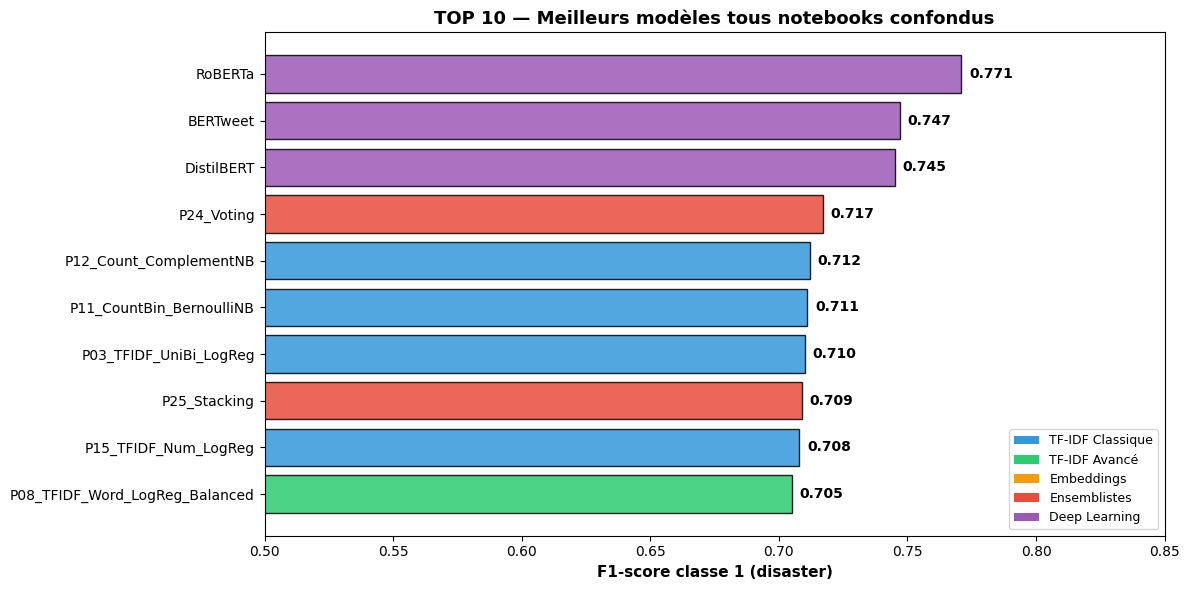

In [6]:
# ── VISUALISATION 1 : TOP 10 MODÈLES ─────────────────────────────────────────
top10 = all_results.head(10)

fig, ax = plt.subplots(figsize=(12, 6))
colors_map = {
    'TF-IDF Classique' : '#3498DB',
    'TF-IDF Avancé'    : '#2ECC71',
    'Embeddings'       : '#F39C12',
    'Ensemblistes'     : '#E74C3C',
    'Deep Learning'    : '#9B59B6'
}
colors = [colors_map[c] for c in top10['categorie']]

bars = ax.barh(top10['pipeline'][::-1], top10['test_f1_class_1'][::-1],
               color=colors[::-1], edgecolor='black', alpha=0.85)

ax.set_xlabel('F1-score classe 1 (disaster)', fontsize=11, fontweight='bold')
ax.set_title('TOP 10 — Meilleurs modèles tous notebooks confondus',
             fontsize=13, fontweight='bold')
ax.set_xlim(0.5, 0.85)

# Annotations
for bar, val in zip(bars, top10['test_f1_class_1'][::-1]):
    ax.text(val + 0.003, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=10, fontweight='bold')

# Légende par catégorie
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=col, label=cat) for cat, col in colors_map.items()]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)

plt.tight_layout()
plt.show()

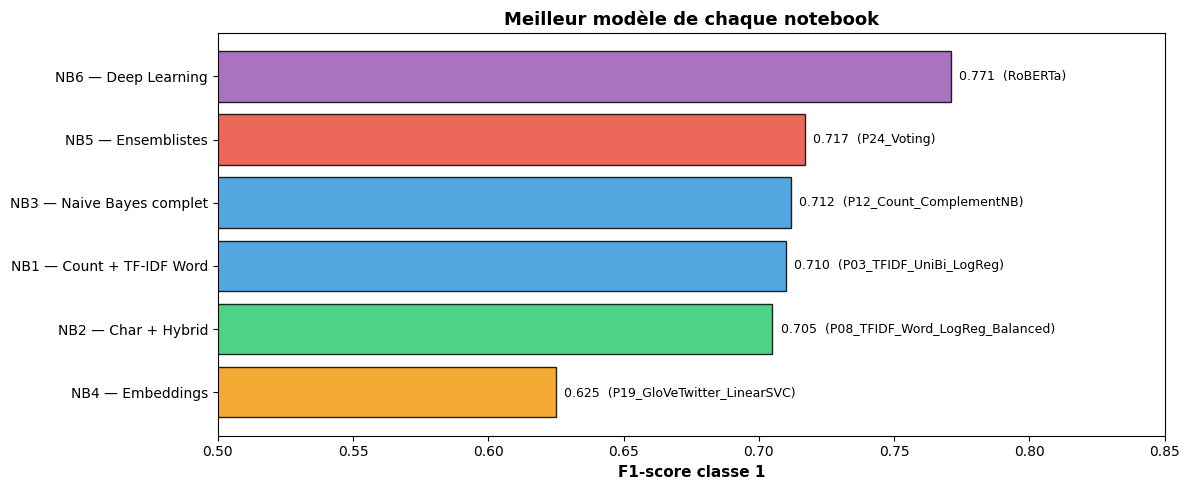

In [7]:
# ── VISUALISATION 2 : MEILLEUR MODÈLE PAR NOTEBOOK ───────────────────────────
best_per_nb = all_results.loc[all_results.groupby('notebook')['test_f1_class_1'].idxmax()]
best_per_nb = best_per_nb.sort_values('test_f1_class_1', ascending=True)

fig, ax = plt.subplots(figsize=(12, 5))
colors = [colors_map[c] for c in best_per_nb['categorie']]
bars = ax.barh(best_per_nb['notebook'], best_per_nb['test_f1_class_1'],
               color=colors, edgecolor='black', alpha=0.85)

ax.set_xlabel('F1-score classe 1', fontsize=11, fontweight='bold')
ax.set_title('Meilleur modèle de chaque notebook',
             fontsize=13, fontweight='bold')
ax.set_xlim(0.5, 0.85)

# Annotations avec pipeline name
for bar, val, pipe in zip(bars, best_per_nb['test_f1_class_1'], best_per_nb['pipeline']):
    ax.text(val + 0.003, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}  ({pipe})', va='center', fontsize=9)

plt.tight_layout()
plt.show()

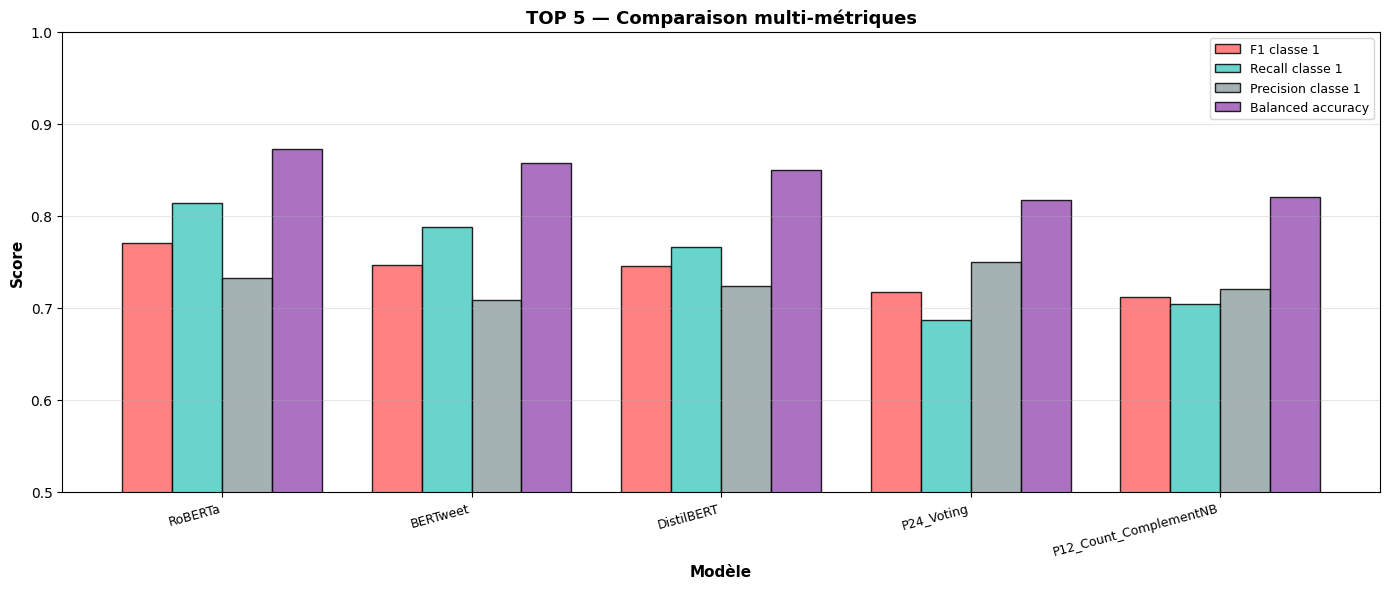

In [8]:
# ── VISUALISATION 3 : MÉTRIQUES MULTI-DIMENSIONS DU TOP 5 ────────────────────
top5 = all_results.head(5)

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(top5))
width = 0.2

metrics = ['test_f1_class_1', 'test_recall_class_1',
           'test_precision_class_1', 'test_balanced_accuracy']
labels  = ['F1 classe 1', 'Recall classe 1', 'Precision classe 1', 'Balanced accuracy']
colors_m = ['#FF6B6B', '#4ECDC4', '#95A5A6', '#9B59B6']

for i, (metric, label, color) in enumerate(zip(metrics, labels, colors_m)):
    ax.bar(x + i*width, top5[metric], width, label=label, color=color,
           edgecolor='black', alpha=0.85)

ax.set_xlabel('Modèle', fontsize=11, fontweight='bold')
ax.set_ylabel('Score', fontsize=11, fontweight='bold')
ax.set_title('TOP 5 — Comparaison multi-métriques', fontsize=13, fontweight='bold')
ax.set_xticks(x + 1.5*width)
ax.set_xticklabels(top5['pipeline'], rotation=15, ha='right', fontsize=9)
ax.legend(fontsize=9)
ax.set_ylim(0.5, 1.0)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [9]:
# ── SAUVEGARDE DU TABLEAU COMPLET POUR STREAMLIT ─────────────────────────────
all_results.to_csv('/content/all_models_comparison.csv', index=False)

print(f"✅ Tableau complet sauvegardé : {len(all_results)} modèles")
print(f"   Meilleur : {all_results.iloc[0]['pipeline']} (F1={all_results.iloc[0]['test_f1_class_1']})")

✅ Tableau complet sauvegardé : 30 modèles
   Meilleur : RoBERTa (F1=0.771)


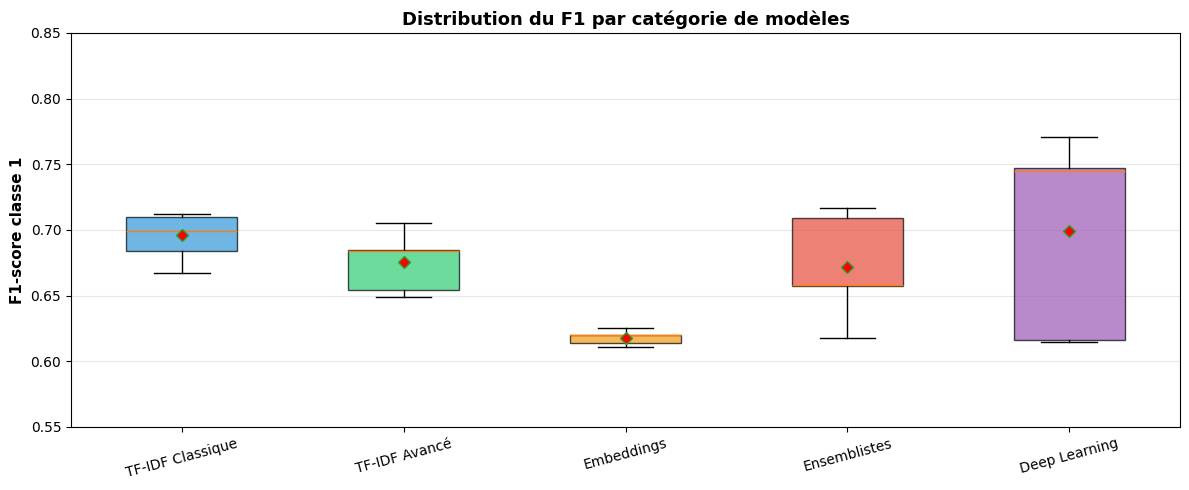

In [10]:
# ── VISUALISATION 4 : F1 PAR CATÉGORIE (BOXPLOT) ─────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

categories = ['TF-IDF Classique', 'TF-IDF Avancé', 'Embeddings',
              'Ensemblistes', 'Deep Learning']
data_by_cat = [all_results[all_results['categorie'] == c]['test_f1_class_1'].values
               for c in categories]

bp = ax.boxplot(data_by_cat, labels=categories, patch_artist=True,
                showmeans=True, meanprops=dict(marker='D', markerfacecolor='red'))

colors_box = ['#3498DB', '#2ECC71', '#F39C12', '#E74C3C', '#9B59B6']
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_ylabel('F1-score classe 1', fontsize=11, fontweight='bold')
ax.set_title('Distribution du F1 par catégorie de modèles',
             fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0.55, 0.85)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [11]:
# ── RÉCAPITULATIF FINAL ──────────────────────────────────────────────────────
print("="*70)
print("RÉCAPITULATIF DU PROJET")
print("="*70)
print(f"\nNombre total de modèles testés : {len(all_results)}")
print(f"\nMeilleur modèle global : {all_results.iloc[0]['pipeline']}")
print(f"   F1 classe 1     : {all_results.iloc[0]['test_f1_class_1']}")
print(f"   Recall classe 1 : {all_results.iloc[0]['test_recall_class_1']}")
print(f"   Precision       : {all_results.iloc[0]['test_precision_class_1']}")
print(f"   Accuracy        : {all_results.iloc[0]['test_accuracy']}")

print(f"\nMeilleur par catégorie :")
for cat in categories:
    subset = all_results[all_results['categorie'] == cat]
    if len(subset) > 0:
        best = subset.iloc[0]
        print(f"   {cat:25s} : {best['pipeline']:30s} F1={best['test_f1_class_1']}")

RÉCAPITULATIF DU PROJET

Nombre total de modèles testés : 30

Meilleur modèle global : RoBERTa
   F1 classe 1     : 0.771
   Recall classe 1 : 0.814
   Precision       : 0.732
   Accuracy        : 0.91

Meilleur par catégorie :
   TF-IDF Classique          : P12_Count_ComplementNB         F1=0.712
   TF-IDF Avancé             : P08_TFIDF_Word_LogReg_Balanced F1=0.705
   Embeddings                : P19_GloVeTwitter_LinearSVC     F1=0.625
   Ensemblistes              : P24_Voting                     F1=0.717
   Deep Learning             : RoBERTa                        F1=0.771


In [13]:
# ── PRÉPARATION DES DONNÉES POUR STREAMLIT ───────────────────────────────────
# 1. Sauvegarde du tableau complet
all_results.to_csv('/content/all_models_comparison.csv', index=False)

# 2. Création d'un JSON avec les meilleurs paramètres et descriptions
import json

models_metadata = {
    'RoBERTa': {
        'description': 'Robustly Optimized BERT Approach — Transformer pré-entraîné sur 160GB de texte',
        'paper': 'https://arxiv.org/abs/1907.11692',
        'year': 2019,
        'parameters': '125M',
        'type': 'Transformer',
        'pros': ['Capture le contexte bidirectionnel', 'Excellente compréhension sémantique', 'Performances état de l\'art'],
        'cons': ['Modèle volumineux', 'Nécessite un GPU pour l\'inférence rapide', 'Temps d\'entraînement long']
    },
    'BERTweet': {
        'description': 'BERT pré-entraîné sur 850M de tweets — spécialisé pour le langage Twitter',
        'paper': 'https://arxiv.org/abs/2005.10200',
        'year': 2020,
        'parameters': '135M',
        'type': 'Transformer',
        'pros': ['Optimisé pour les tweets', 'Gère bien hashtags et @mentions', 'Normalisation Twitter intégrée'],
        'cons': ['Vocabulaire limité au Twitter anglais', 'Modèle volumineux']
    },
    'DistilBERT': {
        'description': 'Version distillée de BERT — 40% plus petit, 60% plus rapide, 97% des performances',
        'paper': 'https://arxiv.org/abs/1910.01108',
        'year': 2019,
        'parameters': '66M',
        'type': 'Transformer léger',
        'pros': ['Très rapide', 'Léger pour le déploiement', 'Performances proches de BERT'],
        'cons': ['Légèrement moins précis que BERT', 'Pas spécialisé tweets']
    },
    'P24_Voting': {
        'description': 'Soft voting entre Logistic Regression, SVC et ComplementNB',
        'year': 2024,
        'parameters': 'N/A',
        'type': 'Ensembliste',
        'pros': ['Combine plusieurs modèles', 'Robuste aux erreurs individuelles', 'Rapide en inférence'],
        'cons': ['Moins performant que les Transformers', 'Plus complexe à maintenir']
    },
    'P12_Count_ComplementNB': {
        'description': 'Naive Bayes complémentaire avec CountVectorizer — adapté au déséquilibre',
        'year': 2024,
        'parameters': 'N/A',
        'type': 'Naive Bayes',
        'pros': ['Très rapide', 'Adapté aux datasets déséquilibrés', 'Faible besoin en données'],
        'cons': ['Hypothèses naïves (indépendance des features)', 'Performances limitées']
    }
}

with open('/content/models_metadata.json', 'w') as f:
    json.dump(models_metadata, f, indent=2, ensure_ascii=False)

print("✅ Métadonnées sauvegardées")

✅ Métadonnées sauvegardées
